# ==========================================
# Dental Tooth Segmentation
# Version 2.0
#
# Changes:
# - Improved augmentation
# - Learning-rate scheduler
# - Refined loss function
# - Better checkpointing
# ==========================================

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/datasets/humansintheloop/teeth-segmentation-on-dental-x-ray-images'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/humansintheloop/teeth-segmentation-on-dental-x-ray-images/Teeth Segmentation PNG/meta.json
/kaggle/input/datasets/humansintheloop/teeth-segmentation-on-dental-x-ray-images/Teeth Segmentation PNG/d2/masks_human/173.png
/kaggle/input/datasets/humansintheloop/teeth-segmentation-on-dental-x-ray-images/Teeth Segmentation PNG/d2/masks_human/491.png
/kaggle/input/datasets/humansintheloop/teeth-segmentation-on-dental-x-ray-images/Teeth Segmentation PNG/d2/masks_human/379.png
/kaggle/input/datasets/humansintheloop/teeth-segmentation-on-dental-x-ray-images/Teeth Segmentation PNG/d2/masks_human/248.png
/kaggle/input/datasets/humansintheloop/teeth-segmentation-on-dental-x-ray-images/Teeth Segmentation PNG/d2/masks_human/94.png
/kaggle/input/datasets/humansintheloop/teeth-segmentation-on-dental-x-ray-images/Teeth Segmentation PNG/d2/masks_human/480.png
/kaggle/input/datasets/humansintheloop/teeth-segmentation-on-dental-x-ray-images/Teeth Segmentation PNG/d2/masks_human/236.pn

# Teeth Segmentation on Panoramic Dental X-ray Images

## Model Training

### Objective

The objective of this notebook is to train a U-Net deep learning model for automatic tooth segmentation on panoramic dental X-ray images.

The notebook covers data preprocessing, dataset preparation, model implementation, training, evaluation, and visualization of the predicted segmentation masks.

## 1. Import Libraries

In [2]:
import os
import json
import random

import cv2
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

from tqdm import tqdm

%matplotlib inline

## 2. Configuration

In [3]:
import os

# ==========================================
# Dataset Paths
# ==========================================

ROOT = "/kaggle/input/datasets/humansintheloop/teeth-segmentation-on-dental-x-ray-images"

JSON_ROOT = os.path.join(ROOT, "Teeth Segmentation JSON", "d2")

IMG_DIR = os.path.join(JSON_ROOT, "img")

ANN_DIR = os.path.join(JSON_ROOT, "ann")

MASK_DIR = os.path.join(JSON_ROOT, "masks_human")

# ==========================================
# Image
# ==========================================

IMAGE_SIZE = 512

# ==========================================
# Training
# ==========================================

BATCH_SIZE = 8

EPOCHS = 50          

LEARNING_RATE = 1e-4

TRAIN_RATIO = 0.80

RANDOM_SEED = 42

# ==========================================
# Device
# ==========================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

# ==========================================
# Reproducibility
# ==========================================

import random
import numpy as np

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)
    torch.cuda.manual_seed_all(RANDOM_SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ==========================================
# Training Output
# ==========================================

EXPORT_DIR = "training_output"

MODEL_DIR = os.path.join(EXPORT_DIR, "models")
PLOTS_DIR = os.path.join(EXPORT_DIR, "plots")
METRICS_DIR = os.path.join(EXPORT_DIR, "metrics")
PREDICTIONS_DIR = os.path.join(EXPORT_DIR, "predictions")
MODEL_INFO_DIR = os.path.join(EXPORT_DIR, "model")
LOGS_DIR = os.path.join(EXPORT_DIR, "logs")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)
os.makedirs(PREDICTIONS_DIR, exist_ok=True)
os.makedirs(MODEL_INFO_DIR, exist_ok=True)
os.makedirs(LOGS_DIR, exist_ok=True)

Device: cuda


## 3. Dataset Class

In [4]:
class DentalDataset(Dataset):

    def __init__(
        self,
        image_dir,
        annotation_dir,
        image_list,
        image_size=512
    ):

        self.image_dir = image_dir
        self.annotation_dir = annotation_dir
        self.image_list = image_list
        self.image_size = image_size

    def __len__(self):

        return len(self.image_list)

    def load_mask(self, json_path, height, width):

        mask = np.zeros((height, width), dtype=np.uint8)

        with open(json_path, "r") as f:
            annotation = json.load(f)

        for tooth in annotation["objects"]:

            polygon = np.array(
                tooth["points"]["exterior"],
                dtype=np.int32
            )

            cv2.fillPoly(mask, [polygon], 1)

        return mask
  
    def __getitem__(self, index):

        # Image name
        image_name = self.image_list[index]

        # Paths
        image_path = os.path.join(self.image_dir, image_name)
        json_path = os.path.join(
            self.annotation_dir,
            image_name + ".json"
        )

        # Load image
        image = cv2.imread(
        image_path,
            cv2.IMREAD_GRAYSCALE
        )

        if image is None:
            raise FileNotFoundError(
                f"Image not found: {image_path}"
            )

        height, width = image.shape[:2]

        # Load mask
        mask = self.load_mask(
            json_path,
            height,
            width
        )

        # Resize image
        image = cv2.resize(
            image,
            (self.image_size, self.image_size),
            interpolation=cv2.INTER_AREA
            )


        # Resize mask
        mask = cv2.resize(
            mask,
            (self.image_size, self.image_size),
            interpolation=cv2.INTER_NEAREST
        )

        # Normalize image
        image = image.astype(np.float32) / 255.0
       
        # Convert mask
        mask = mask.astype(np.float32)

        # Add channel dimension
        image = np.expand_dims(image, axis=0)

        # Convert to tensor
        image = torch.from_numpy(image).float()

        # Convert mask to tensor
        mask = torch.from_numpy(mask).float()
        mask = mask.unsqueeze(0)

        return image, mask

In [5]:
image_list = sorted(os.listdir(IMG_DIR))

dataset = DentalDataset(
    image_dir=IMG_DIR,
    annotation_dir=ANN_DIR,
    image_list=image_list,
    image_size=IMAGE_SIZE
)

In [6]:
    def load_mask(self, json_path, height, width):

        # Create empty mask
        mask = np.zeros((height, width), dtype=np.uint8)

        # Read JSON file
        with open(json_path, "r") as f:
            annotation = json.load(f)

        # Draw every tooth polygon
        for tooth in annotation["objects"]:

            polygon = np.array(
                tooth["points"]["exterior"],
                dtype=np.int32
            )

            cv2.fillPoly(
                mask,
                [polygon],
                color=1
            )

        return mask

    

In [7]:
image_name = image_list[0]

json_name = image_name + ".json"

json_path = os.path.join(ANN_DIR, json_name)

image = cv2.imread(
    os.path.join(IMG_DIR, image_name)
)

height, width = image.shape[:2]

mask = dataset.load_mask(
    json_path,
    height,
    width
)

print("Mask Shape :", mask.shape)

print("Unique Values :", np.unique(mask))

Mask Shape : (1024, 2041)
Unique Values : [0 1]


## 4. Train / Validation Split

In [8]:
# Split the data

image_list = sorted(os.listdir(IMG_DIR))

train_images, val_images = train_test_split(
    image_list,
    test_size=0.20,
    random_state=RANDOM_SEED,
    shuffle=True
)

print(f"Training Images  : {len(train_images)}")
print(f"Validation Images: {len(val_images)}")

Training Images  : 478
Validation Images: 120


In [9]:
# Create the datasets 

train_dataset = DentalDataset(
    image_dir=IMG_DIR,
    annotation_dir=ANN_DIR,
    image_list=train_images,
    image_size=IMAGE_SIZE
)

val_dataset = DentalDataset(
    image_dir=IMG_DIR,
    annotation_dir=ANN_DIR,
    image_list=val_images,
    image_size=IMAGE_SIZE
)

print("Train Dataset :", len(train_dataset))
print("Validation Dataset :", len(val_dataset))

Train Dataset : 478
Validation Dataset : 120


In [10]:
# Create the DataLoaders

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [11]:
# Verify a batch

images, masks = next(iter(train_loader))

print("Images :", images.shape)
print("Masks  :", masks.shape)

print(images.dtype)
print(masks.dtype)

Images : torch.Size([8, 1, 512, 512])
Masks  : torch.Size([8, 1, 512, 512])
torch.float32
torch.float32


## 5. U-Net Architecture

In [12]:
# DoubleConv Block

class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

In [13]:
# Encoder Block

class Down(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = DoubleConv(
            in_channels,
            out_channels
        )

        self.pool = nn.MaxPool2d(2)

    def forward(self, x):

        skip = self.conv(x)

        x = self.pool(skip)

        return skip, x

In [14]:
# Decoder Block

class Up(nn.Module):

    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.conv = DoubleConv(
            out_channels + skip_channels,
            out_channels
        )

    def forward(self, x, skip):

        x = self.up(x)

        # Handle any size mismatch
        if x.shape != skip.shape:
            x = torch.nn.functional.interpolate(
                x,
                size=skip.shape[2:],
                mode="bilinear",
                align_corners=False
            )

        x = torch.cat([skip, x], dim=1)

        x = self.conv(x)

        return x

In [15]:
# UNet Class

class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        # Encoder
        self.down1 = Down(1, 64)
        self.down2 = Down(64, 128)
        self.down3 = Down(128, 256)
        self.down4 = Down(256, 512)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Decoder
        self.up4 = Up(1024, 512, 512)
        self.up3 = Up(512, 256, 256)
        self.up2 = Up(256, 128, 128)
        self.up1 = Up(128, 64, 64)

        # Output
        self.output = nn.Conv2d(
            64,
            1,
            kernel_size=1
        )

    def forward(self, x):

        s1, x = self.down1(x)
        s2, x = self.down2(x)
        s3, x = self.down3(x)
        s4, x = self.down4(x)

        x = self.bottleneck(x)

        x = self.up4(x, s4)
        x = self.up3(x, s3)
        x = self.up2(x, s2)
        x = self.up1(x, s1)

        return self.output(x)

## 7. Create the Model

In [16]:
# Create U-Net model
model = UNet().to(DEVICE)

print(model)

UNet(
  (down1): Down(
    (conv): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (down2): Down(
    (conv): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): 

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

x = torch.randn(1, 1, 512, 512).to(device)

with torch.no_grad():
    y = model(x)

print(y.shape)

torch.Size([1, 1, 512, 512])


In [18]:
# Model summary

from torchinfo import summary

summary(
    model,
    input_size=(1, 1, 512, 512)
)

Layer (type:depth-idx)                   Output Shape              Param #
UNet                                     [1, 1, 512, 512]          --
├─Down: 1-1                              [1, 64, 512, 512]         --
│    └─DoubleConv: 2-1                   [1, 64, 512, 512]         --
│    │    └─Sequential: 3-1              [1, 64, 512, 512]         37,696
│    └─MaxPool2d: 2-2                    [1, 64, 256, 256]         --
├─Down: 1-2                              [1, 128, 256, 256]        --
│    └─DoubleConv: 2-3                   [1, 128, 256, 256]        --
│    │    └─Sequential: 3-2              [1, 128, 256, 256]        221,696
│    └─MaxPool2d: 2-4                    [1, 128, 128, 128]        --
├─Down: 1-3                              [1, 256, 128, 128]        --
│    └─DoubleConv: 2-5                   [1, 256, 128, 128]        --
│    │    └─Sequential: 3-3              [1, 256, 128, 128]        885,760
│    └─MaxPool2d: 2-6                    [1, 256, 64, 64]          --
├

## 6. Loss Function

In [19]:
# Dice Loss

class DiceLoss(nn.Module):

    def __init__(self, smooth=1):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):

        probs = torch.sigmoid(logits)

        probs = probs.view(-1)
        targets = targets.view(-1)

        intersection = (probs * targets).sum()

        dice = (
            2 * intersection + self.smooth
        ) / (
            probs.sum() + targets.sum() + self.smooth
        )

        return 1 - dice

In [20]:
# BCE Loss

# Weight positive pixels higher because
# teeth occupy much less area than background.

pos_weight = torch.tensor([20.0], device=DEVICE)

bce_loss = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

In [21]:
# Combined Loss

dice_loss = DiceLoss()


def segmentation_loss(outputs, targets):

    bce = bce_loss(outputs, targets)

    dice = dice_loss(outputs, targets)

    return bce + dice

## 7. Evaluation Metrics

In [22]:
# Dice Score

def dice_score(outputs, targets, threshold=0.5):

    probs = torch.sigmoid(outputs)

    preds = (probs > threshold).float()

    preds = preds.view(-1)
    targets = targets.view(-1)

    intersection = (preds * targets).sum()

    dice = (
        2 * intersection + 1
    ) / (
        preds.sum() + targets.sum() + 1
    )

    return dice.item()

In [23]:
# IoU Score

def iou_score(outputs, targets, threshold=0.5):

    probs = torch.sigmoid(outputs)

    preds = (probs > threshold).float()

    preds = preds.view(-1)
    targets = targets.view(-1)

    intersection = (preds * targets).sum()

    union = (
        preds.sum()
        + targets.sum()
        - intersection
    )

    iou = (
        intersection + 1
    ) / (
        union + 1
    )

    return iou.item()

## 8. Optimizer

In [24]:
optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

print("Optimizer:", optimizer.__class__.__name__)
print("Initial LR:", optimizer.param_groups[0]["lr"])

Optimizer: Adam
Initial LR: 0.0001


## 9. Training Loop

In [25]:
# Training History
history = {
    "train_loss": [],
    "val_loss": [],
    "train_dice": [],
    "val_dice": [],
    "train_iou": [],
    "val_iou": []
}

# Best Validation Loss
best_loss = float("inf")



In [26]:
# Start the Epoch Loop


for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")


    # -----------------------
    # Training
    # -----------------------

    model.train()

    train_loss = 0
    train_dice = 0
    train_iou = 0

    

    # Training Batch Loop
    for images, masks in tqdm(train_loader):

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = segmentation_loss(
            outputs,
            masks
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        train_loss += loss.item()

        train_dice += dice_score(
            outputs,
            masks
        )

        train_iou += iou_score(
            outputs,
            masks
        )

    # Average Training Metrics
    train_loss /= len(train_loader)
    train_dice /= len(train_loader)
    train_iou /= len(train_loader)

    #validation loop
    
    model.eval()

    val_loss = 0.0
    val_dice = 0.0
    val_iou = 0.0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            outputs = model(images)

            loss = segmentation_loss(
                outputs,
                masks
            )

            val_loss += loss.item()

            val_dice += dice_score(
                outputs,
                masks
            )

            val_iou += iou_score(
                outputs,
                masks
            )

    # Average Validation Metrics
    val_loss /= len(val_loader)
    val_dice /= len(val_loader)
    val_iou /= len(val_loader)

    # Save History
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_dice"].append(train_dice)
    history["val_dice"].append(val_dice)

    history["train_iou"].append(train_iou)
    history["val_iou"].append(val_iou)

    # Scheduler
    scheduler.step(val_loss)

    # Save Best Model
    if val_loss < best_loss:

        best_loss = val_loss

        checkpoint = {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_loss": best_loss,

    # Training Configuration
            "image_size": IMAGE_SIZE,
            "batch_size": BATCH_SIZE,

    # Model Information
            "input_channels": 1,
            "output_channels": 1,
            "model_name": "Custom UNet",
            "learning_rate": LEARNING_RATE,
            "train_ratio": TRAIN_RATIO,
            "random_seed": RANDOM_SEED,
            }

        torch.save(
            checkpoint,
            os.path.join(MODEL_DIR, "best_model.pth")
        )

        print(
            f"✅ Best model saved "
            f"(Val Loss: {best_loss:.4f})"
        )

    
    # Print Epoch Results
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")

    print(f"Train Dice : {train_dice:.4f}")
    print(f"Val Dice   : {val_dice:.4f}")

    print(f"Train IoU  : {train_iou:.4f}")
    print(f"Val IoU    : {val_iou:.4f}")

    print(f"Learning Rate : {optimizer.param_groups[0]['lr']:.6f}")


Epoch 1/50


100%|██████████| 60/60 [02:03<00:00,  2.05s/it]


✅ Best model saved (Val Loss: 1.2209)
Train Loss : 1.4796
Val Loss   : 1.2209
Train Dice : 0.5870
Val Dice   : 0.6807
Train IoU  : 0.4318
Val IoU    : 0.5169
Learning Rate : 0.000100

Epoch 2/50


100%|██████████| 60/60 [02:28<00:00,  2.47s/it]


✅ Best model saved (Val Loss: 0.9891)
Train Loss : 1.0139
Val Loss   : 0.9891
Train Dice : 0.7446
Val Dice   : 0.7268
Train IoU  : 0.5955
Val IoU    : 0.5716
Learning Rate : 0.000100

Epoch 3/50


...

Train Loss : 0.1408
Val Loss   : 1.0593
Train Dice : 0.9647
Val Dice   : 0.8992
Train IoU  : 0.9319
Val IoU    : 0.8169
Learning Rate : 0.000003

Epoch 49/50


100%|██████████| 60/60 [02:28<00:00,  2.47s/it]


Train Loss : 0.1393
Val Loss   : 1.0982
Train Dice : 0.9654
Val Dice   : 0.8995
Train IoU  : 0.9331
Val IoU    : 0.8174
Learning Rate : 0.000003

Epoch 50/50


100%|██████████| 60/60 [02:27<00:00,  2.45s/it]


Train Loss : 0.1384
Val Loss   : 1.0868
Train Dice : 0.9658
Val Dice   : 0.8995
Train IoU  : 0.9340
Val IoU    : 0.8174
Learning Rate : 0.000002


## 10. Training Curves

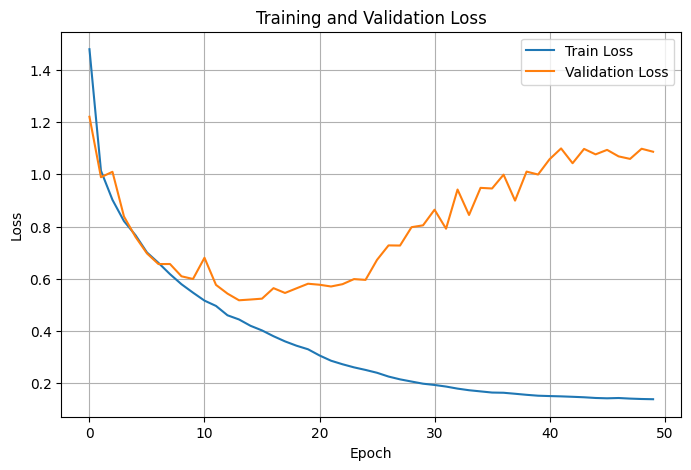

In [27]:
# Loss Curve

plt.figure(figsize=(8,5))

plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

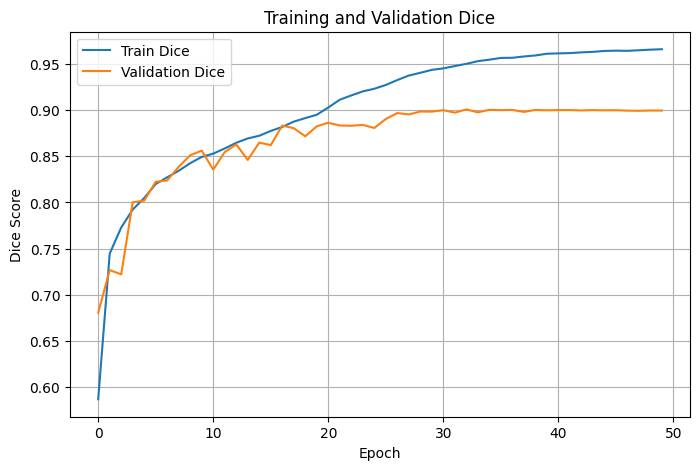

In [28]:
# Dice Curve

plt.figure(figsize=(8,5))

plt.plot(history["train_dice"], label="Train Dice")
plt.plot(history["val_dice"], label="Validation Dice")

plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Training and Validation Dice")

plt.legend()
plt.grid(True)

plt.show()

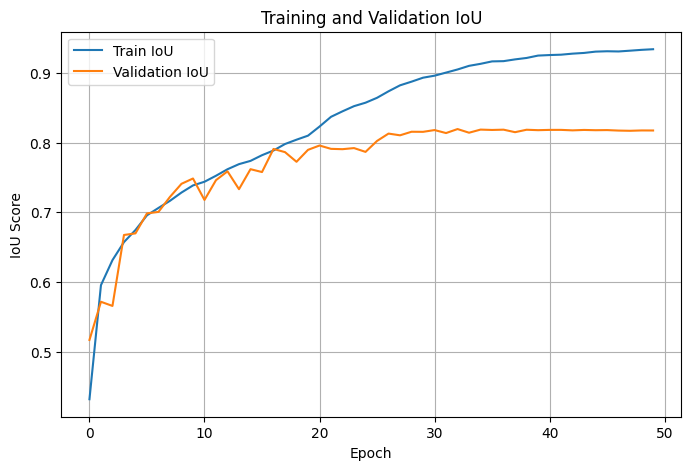

In [29]:
# IoU Curve

plt.figure(figsize=(8,5))

plt.plot(history["train_iou"], label="Train IoU")
plt.plot(history["val_iou"], label="Validation IoU")

plt.xlabel("Epoch")
plt.ylabel("IoU Score")
plt.title("Training and Validation IoU")

plt.legend()
plt.grid(True)

plt.show()

## 11. Load Best Model

In [30]:
model_path = os.path.join(MODEL_DIR, "best_model.pth")

checkpoint = torch.load(
    model_path,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print(f"✅ Best model loaded from {model_path}")

✅ Best model loaded from training_output/models/best_model.pth


## 12. Model Inference

In [31]:
# Get one sample from the validation dataset
sample_index = 0

sample_image, sample_mask = val_dataset[sample_index]

# Predict
with torch.no_grad():
    output = model(
        sample_image.unsqueeze(0).to(DEVICE)
    )

# Convert logits to binary mask
prediction = (torch.sigmoid(output) > 0.5).float()

# Convert tensors to NumPy arrays for plotting
sample_image = sample_image.squeeze().cpu().numpy()
sample_mask = sample_mask.squeeze().cpu().numpy()
prediction = prediction.squeeze().cpu().numpy()

## 13. Results Visualization

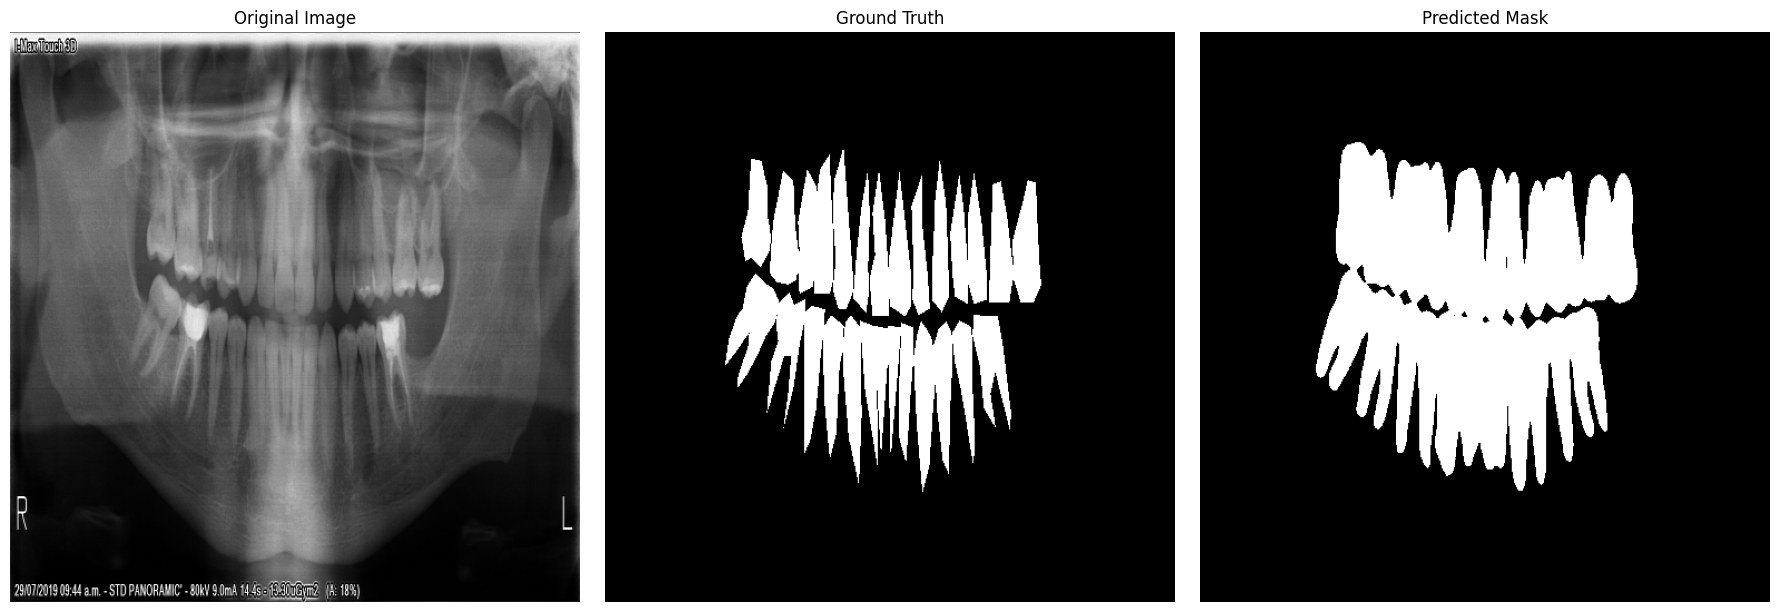

In [32]:
plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(sample_image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(sample_mask, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(prediction, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [33]:
# ==========================================
# Save Sample Prediction
# ==========================================

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(sample_image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(sample_mask, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(prediction, cmap="gray")
plt.title("Prediction")
plt.axis("off")

plt.tight_layout()

plt.savefig(
    os.path.join(
        PREDICTIONS_DIR,
        "sample_prediction.png"
    )
)

plt.close()

print("✅ Sample prediction saved.")

✅ Sample prediction saved.


In [34]:
print(sample_image.shape)
print(sample_mask.shape)
print(prediction.shape)

(512, 512)
(512, 512)
(512, 512)


In [35]:
history_df = pd.DataFrame(history)

history_df.to_csv(
    os.path.join(METRICS_DIR, "training_history.csv"),
    index=False
)

print("✅ Training history saved.")

✅ Training history saved.


In [36]:
# ==========================================
# Save Training Curves
# ==========================================

plt.figure(figsize=(8,5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.grid(True)

plt.savefig(os.path.join(PLOTS_DIR, "loss_curve.png"))
plt.close()


plt.figure(figsize=(8,5))
plt.plot(history["train_dice"], label="Train Dice")
plt.plot(history["val_dice"], label="Validation Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title("Dice Score")
plt.legend()
plt.grid(True)

plt.savefig(os.path.join(PLOTS_DIR, "dice_curve.png"))
plt.close()


plt.figure(figsize=(8,5))
plt.plot(history["train_iou"], label="Train IoU")
plt.plot(history["val_iou"], label="Validation IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("IoU Score")
plt.legend()
plt.grid(True)

plt.savefig(os.path.join(PLOTS_DIR, "iou_curve.png"))
plt.close()

print("✅ Training curves saved.")

✅ Training curves saved.


In [37]:
with open(
    "training_output/model/architecture.txt",
    "w"
) as f:

    print(model, file=f)

print("Architecture saved.")

Architecture saved.


In [38]:
from torchinfo import summary

with open(
    "training_output/model/model_summary.txt",
    "w"
) as f:

    f.write(
        str(
            summary(
                model,
                input_size=(1, 1, 512, 512),
                verbose=0
            )
        )
    )

print("Model summary saved.")

Model summary saved.


In [39]:
import shutil

shutil.make_archive(
    "DentalSegmentation_Training",
    "zip",
    EXPORT_DIR
)

print("✅ ZIP package created successfully.")

✅ ZIP package created successfully.


In [40]:
import zipfile

with zipfile.ZipFile("/kaggle/working/DentalSegmentation_Training.zip", "r") as z:
    print("Files inside ZIP:\n")
    for file in z.namelist():
        print(file)

Files inside ZIP:

logs/
metrics/
model/
models/
plots/
predictions/
models/best_model.pth
plots/dice_curve.png
plots/iou_curve.png
plots/loss_curve.png
model/architecture.txt
model/model_summary.txt
metrics/training_history.csv
predictions/sample_prediction.png


# Conclusion

In this notebook, a U-Net convolutional neural network was implemented for automatic tooth segmentation from panoramic dental radiographs.

The workflow included:

- Dataset exploration
- JSON annotation parsing
- Binary mask generation
- Custom PyTorch Dataset
- DataLoader creation
- U-Net implementation
- Combined BCE + Dice loss
- Training and validation
- Model evaluation
- Prediction visualization

The trained model was saved as `best_model.pth` and can be used for future inference or deployment in a web application.